<a href="https://colab.research.google.com/github/Shrutisru/academic_research/blob/main/week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q opencv-python numpy pandas matplotlib scipy evo pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.4/162.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.9/144.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.3 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset root : /content/uav_project/data/mav0
সব পাথ ঠিক আছে ✅
OpenCV: 4.14.0
Camera matrix K:
 [[458.654   0.    367.215]
 [  0.    457.296 248.375]
 [  0.      0.      1.   ]]
Distortion coeffs: [-2.83408110e-01  7.39590700e-02  1.93590000e-04  1.76187114e-05]
মোট ক্যামেরা ফ্রেম: 3638
ব্যবহারযোগ্য (common window) ফ্রেম: 3638
Ground-truth samples: 36382
প্রথম ফ্রেমের ফিচার সংখ্যা: 2500
VO লুপ শুরু হচ্ছে...
Frame   200/3638 | Success:   174 | Failed:    26 | Recent mean inliers: 1211.6
Frame  1000/3638 | Success:   502 | Failed:   498 | Recent mean inliers: 1465.4
Frame  1200/3638 | Success:   688 | Failed:   512 | Recent mean inliers: 1515.4
Frame  1600/3638 | Success:   991 | Failed:   609 | Recent mean inliers: 1092.4
Frame  1800/3638 | Success:  1146 | Failed:   654 | Recent mean inliers: 1494.9
Frame  2000/3638 | Success:  1319 | Failed:   681 | Recent m

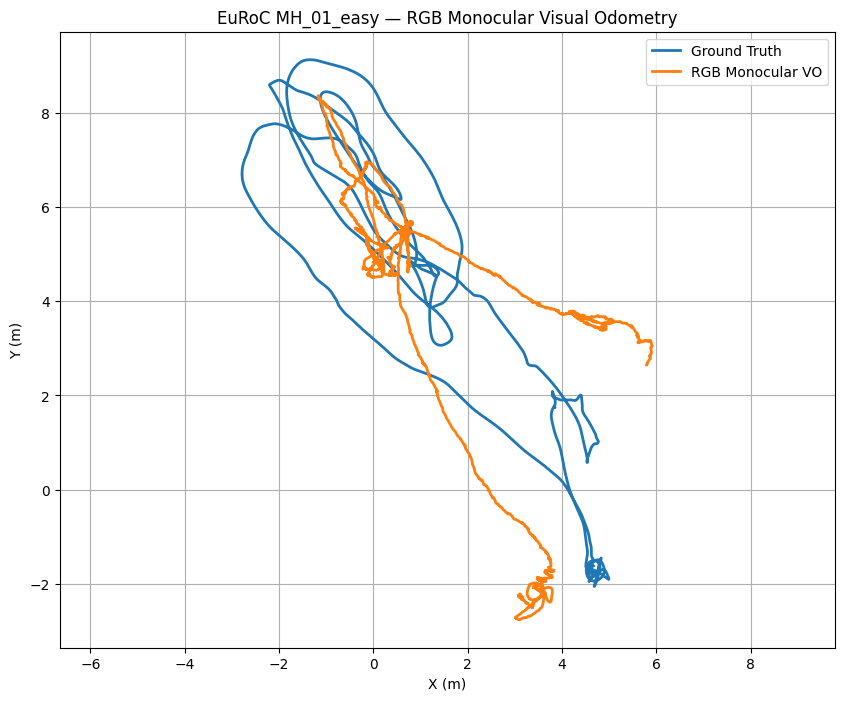

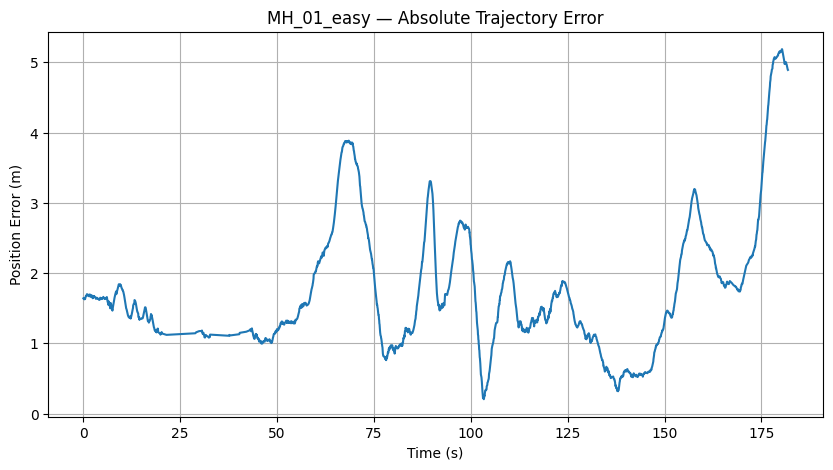


WEEK 2 VO BASELINE — সারাংশ
Dataset                 : MH_01_easy
Method                  : OpenCV ORB Monocular VO
Successful frame pairs  : 2594
Failed frame pairs      : 1043
Estimated poses         : 2595
Monocular scale factor  : 0.028032
ATE RMSE                : 2.007086 m
RPE RMSE (1s)           : 0.438176 m

Results directory: /content/uav_project/results


In [1]:
# -*- coding: utf-8 -*-
"""
Week 2 — Monocular Visual Odometry Baseline (EuRoC MH_01_easy)
=================================================================
এই স্ক্রিপ্টটি নতুন করে, পরিষ্কারভাবে লেখা হয়েছে — কোনো ডুপ্লিকেট কোড নেই।
Google Colab-এ প্রতিটি ধাপ আলাদা সেলে (উপর থেকে নিচে ক্রমানুসারে) রান করুন।

Roadmap অনুযায়ী Week 2-এর লক্ষ্য:
  - পরিষ্কার (clean) EuRoC সিকোয়েন্সে একটা RGB-only VO baseline চালানো
  - Ground truth-এর বিপরীতে ATE/RPE হিসাব করা
  - Estimated vs Ground-truth trajectory প্লট করা
"""

# ============================================================
# ধাপ ১ — Google Drive মাউন্ট ও ডেটাসেট প্রস্তুত করা
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile

zip_path = "/content/drive/MyDrive/MH_01_easy.zip"
work_dir = "/content/uav_project"
extract_dir = f"{work_dir}/data"

os.makedirs(work_dir, exist_ok=True)

assert os.path.exists(zip_path), f"ZIP ফাইল পাওয়া যায়নি: {zip_path}"

# আগে থেকে extract করা থাকলে আবার extract করব না (সময় বাঁচবে)
dataset_root = None
if os.path.exists(extract_dir):
    for root, dirs, files in os.walk(extract_dir):
        if "mav0" in dirs:
            dataset_root = os.path.join(root, "mav0")
            break

if dataset_root is None:
    os.makedirs(extract_dir, exist_ok=True)
    print("Extracting ZIP... (এটা কিছুটা সময় নিতে পারে)")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    for root, dirs, files in os.walk(extract_dir):
        if "mav0" in dirs:
            dataset_root = os.path.join(root, "mav0")
            break

assert dataset_root is not None, "mav0 ফোল্ডার খুঁজে পাওয়া যায়নি — ZIP-এর ভেতরের structure চেক করুন।"

cam0_dir = os.path.join(dataset_root, "cam0")
cam0_data = os.path.join(cam0_dir, "data")
cam0_csv = os.path.join(cam0_dir, "data.csv")
sensor_yaml = os.path.join(cam0_dir, "sensor.yaml")

gt_dir = os.path.join(dataset_root, "state_groundtruth_estimate0")
gt_csv = os.path.join(gt_dir, "data.csv")

for p in [cam0_data, cam0_csv, sensor_yaml, gt_csv]:
    assert os.path.exists(p), f"প্রয়োজনীয় ফাইল/ফোল্ডার পাওয়া যায়নি: {p}"

print("Dataset root :", dataset_root)
print("সব পাথ ঠিক আছে ✅")


# ============================================================
# ধাপ ২ — প্রয়োজনীয় প্যাকেজ ইনস্টল ও ইম্পোর্ট
# ============================================================

# !pip install -q opencv-python numpy pandas matplotlib scipy evo pyyaml

import cv2
import yaml
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
from scipy.spatial.transform import Rotation as SciRot

results_dir = os.path.join(work_dir, "results")
# প্রতিবার ফ্রেশ রান শুরু করতে পুরোনো results ফোল্ডার মুছে ফেলা হচ্ছে —
# যাতে পুরোনো .zip/.tum ফাইল থেকে গিয়ে পরে কনফিউশন বা overwrite-prompt সমস্যা না হয়
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

print("OpenCV:", cv2.__version__)


# ============================================================
# ধাপ ৩ — ক্যামেরা ক্যালিব্রেশন (sensor.yaml থেকে সরাসরি লোড)
# ============================================================
# আগে fx, fy, cx, cy হাতে টাইপ করা হতো — এখন yaml থেকেই পড়া হচ্ছে,
# যাতে টাইপো/ভুলের সুযোগ না থাকে।

with open(sensor_yaml, "r") as f:
    sensor_data = yaml.safe_load(f)

fx, fy, cx, cy = sensor_data["intrinsics"]
dist_coeffs = np.array(sensor_data["distortion_coefficients"], dtype=np.float64)

K = np.array([
    [fx, 0.0, cx],
    [0.0, fy, cy],
    [0.0, 0.0, 1.0]
], dtype=np.float64)

print("Camera matrix K:\n", K)
print("Distortion coeffs:", dist_coeffs)


# ============================================================
# ধাপ ৪ — cam0 ও ground-truth CSV লোড এবং কমন টাইম-উইন্ডো বের করা
# ============================================================

cam_df = pd.read_csv(cam0_csv)
gt_df = pd.read_csv(gt_csv)

cam_time_col = "#timestamp [ns]"
cam_file_col = "filename"

gt_time_col = "#timestamp"
gt_x_col = " p_RS_R_x [m]"
gt_y_col = " p_RS_R_y [m]"
gt_z_col = " p_RS_R_z [m]"

cam_df[cam_time_col] = pd.to_numeric(cam_df[cam_time_col])
gt_df[gt_time_col] = pd.to_numeric(gt_df[gt_time_col])

start_time = max(cam_df[cam_time_col].min(), gt_df[gt_time_col].min())
end_time = min(cam_df[cam_time_col].max(), gt_df[gt_time_col].max())

cam_df = cam_df[
    (cam_df[cam_time_col] >= start_time) & (cam_df[cam_time_col] <= end_time)
].reset_index(drop=True)

print("মোট ক্যামেরা ফ্রেম:", len(cam_df))
print("ব্যবহারযোগ্য (common window) ফ্রেম:", len(cam_df))
print("Ground-truth samples:", len(gt_df))


# ============================================================
# ধাপ ৫ — ORB ডিটেক্টর ও ম্যাচার সেটআপ
# ============================================================

orb = cv2.ORB_create(
    nfeatures=2500,
    scaleFactor=1.2,
    nlevels=8,
    edgeThreshold=31,
    patchSize=31,
    fastThreshold=20
)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)


def load_image(path):
    """গ্রেস্কেলে ছবি পড়ে, EuRoC ক্যালিব্রেশন দিয়ে undistort করে।"""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return cv2.undistort(img, K, dist_coeffs)


# ============================================================
# ধাপ ৬ — মূল VO লুপ (frame-to-frame Essential Matrix VO)
# ============================================================

R_wc = np.eye(3, dtype=np.float64)
t_wc = np.zeros((3, 1), dtype=np.float64)

estimated_positions = []
estimated_rotations = []
estimated_timestamps = []

estimated_positions.append(t_wc.reshape(3))
estimated_rotations.append(R_wc.copy())
estimated_timestamps.append(int(cam_df.iloc[0][cam_time_col]))

first_path = os.path.join(cam0_data, str(cam_df.iloc[0][cam_file_col]))
prev_img = load_image(first_path)
assert prev_img is not None, f"প্রথম ছবি পড়া যায়নি: {first_path}"

prev_kp, prev_des = orb.detectAndCompute(prev_img, None)
assert prev_des is not None and len(prev_kp) >= 20, "প্রথম ফ্রেমে যথেষ্ট ORB ফিচার নেই।"

print("প্রথম ফ্রেমের ফিচার সংখ্যা:", len(prev_kp))
print("VO লুপ শুরু হচ্ছে...")

successful_pairs = 0
failed_pairs = 0
inlier_counts = []

for i in range(1, len(cam_df)):

    img_path = os.path.join(cam0_data, str(cam_df.iloc[i][cam_file_col]))
    curr_img = load_image(img_path)
    if curr_img is None:
        failed_pairs += 1
        continue

    curr_kp, curr_des = orb.detectAndCompute(curr_img, None)
    if curr_des is None or len(curr_kp) < 20:
        failed_pairs += 1
        continue

    try:
        knn_matches = bf.knnMatch(prev_des, curr_des, k=2)
    except cv2.error:
        failed_pairs += 1
        continue

    good_matches = [m for pair in knn_matches if len(pair) == 2
                     for m, n in [pair] if m.distance < 0.75 * n.distance]

    if len(good_matches) < 8:
        failed_pairs += 1
        prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
        continue

    pts_prev = np.float32([prev_kp[m.queryIdx].pt for m in good_matches])
    pts_curr = np.float32([curr_kp[m.trainIdx].pt for m in good_matches])

    E, mask_E = cv2.findEssentialMat(
        pts_prev, pts_curr, K, method=cv2.RANSAC, prob=0.999, threshold=1.0
    )
    if E is None or mask_E is None:
        failed_pairs += 1
        prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
        continue

    inlier_mask = mask_E.ravel().astype(bool)
    pts_prev_in = pts_prev[inlier_mask]
    pts_curr_in = pts_curr[inlier_mask]
    inlier_counts.append(len(pts_prev_in))

    if len(pts_prev_in) < 8:
        failed_pairs += 1
        prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
        continue

    try:
        retval, R_rel, t_rel, pose_mask = cv2.recoverPose(E, pts_prev_in, pts_curr_in, K)
    except cv2.error:
        failed_pairs += 1
        prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
        continue

    if retval < 8:
        failed_pairs += 1
        prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
        continue

    # পোজ আপডেট: T_wc_new = T_wc_old * inverse(T_prev->curr)
    R_wc = R_wc @ R_rel.T
    t_wc = t_wc - R_wc @ t_rel

    estimated_positions.append(t_wc.reshape(3))
    estimated_rotations.append(R_wc.copy())
    estimated_timestamps.append(int(cam_df.iloc[i][cam_time_col]))
    successful_pairs += 1

    prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des

    if i % 200 == 0:
        mean_in = np.mean(inlier_counts[-50:]) if inlier_counts else 0
        print(f"Frame {i:5d}/{len(cam_df)} | Success: {successful_pairs:5d} | "
              f"Failed: {failed_pairs:5d} | Recent mean inliers: {mean_in:.1f}")

estimated_positions = np.asarray(estimated_positions, dtype=np.float64)
estimated_rotations = np.asarray(estimated_rotations, dtype=np.float64)
estimated_timestamps = np.asarray(estimated_timestamps, dtype=np.int64)

print("\nVO শেষ — Success:", successful_pairs, "| Failed:", failed_pairs)
print("মোট estimated poses:", len(estimated_positions))


# ============================================================
# ধাপ ৭ — Ground truth-কে estimated timestamps-এ ইন্টারপোলেট করা
# ============================================================

gt_time = gt_df[gt_time_col].to_numpy(dtype=np.float64)
gt_position = np.column_stack([
    gt_df[gt_x_col].to_numpy(dtype=np.float64),
    gt_df[gt_y_col].to_numpy(dtype=np.float64),
    gt_df[gt_z_col].to_numpy(dtype=np.float64)
])

gt_time, unique_idx = np.unique(gt_time, return_index=True)
gt_position = gt_position[unique_idx]

gt_interp = np.zeros_like(estimated_positions)
for axis in range(3):
    gt_interp[:, axis] = np.interp(
        estimated_timestamps.astype(np.float64), gt_time, gt_position[:, axis]
    )

print("GT interpolated shape:", gt_interp.shape)


# ============================================================
# ধাপ ৮ — Sim(3) (Umeyama) অ্যালাইনমেন্ট
# ============================================================
# মনোকুলার VO-এর scale অজানা থাকে বলে rotation + translation + scale
# — তিনটাই মিলিয়ে ground truth-এর সাথে align করতে হয়।

def umeyama_alignment(source, target, with_scale=True):
    source = np.asarray(source)
    target = np.asarray(target)
    n = source.shape[0]

    mu_src = source.mean(axis=0)
    mu_tgt = target.mean(axis=0)

    src_c = source - mu_src
    tgt_c = target - mu_tgt

    cov = (tgt_c.T @ src_c) / n
    U, D, Vt = np.linalg.svd(cov)

    S = np.eye(3)
    if np.linalg.det(U @ Vt) < 0:
        S[-1, -1] = -1

    R = U @ S @ Vt

    if with_scale:
        var_src = np.sum(src_c ** 2) / n
        scale = np.sum(D * np.diag(S)) / var_src
    else:
        scale = 1.0

    t = mu_tgt - scale * (R @ mu_src)
    aligned = scale * (R @ source.T).T + t
    return aligned, scale, R, t


estimated_aligned, alignment_scale, R_align, t_align = umeyama_alignment(
    estimated_positions, gt_interp, with_scale=True
)

print("Alignment scale factor:", alignment_scale)


# ============================================================
# ধাপ ৯ — ATE হিসাব (manual)
# ============================================================

ate_errors = np.linalg.norm(estimated_aligned - gt_interp, axis=1)
ate_rmse = np.sqrt(np.mean(ate_errors ** 2))
ate_mean = np.mean(ate_errors)
ate_median = np.median(ate_errors)
ate_max = np.max(ate_errors)

print("\n--- ATE (manual) ---")
print(f"RMSE   : {ate_rmse:.6f} m")
print(f"Mean   : {ate_mean:.6f} m")
print(f"Median : {ate_median:.6f} m")
print(f"Max    : {ate_max:.6f} m")


# ============================================================
# ধাপ ১০ — RPE হিসাব (manual, 1-সেকেন্ড ইন্টারভালে)
# ============================================================
# EuRoC cam0 ≈ 20 Hz, তাই 20 ফ্রেম ≈ 1 সেকেন্ড

delta_frames = 20
rpe_errors = []

for i in range(len(estimated_aligned) - delta_frames):
    j = i + delta_frames
    est_delta = estimated_aligned[j] - estimated_aligned[i]
    gt_delta = gt_interp[j] - gt_interp[i]
    rpe_errors.append(np.linalg.norm(est_delta - gt_delta))

rpe_errors = np.asarray(rpe_errors)
rpe_rmse = np.sqrt(np.mean(rpe_errors ** 2)) if len(rpe_errors) else float("nan")

print("\n--- RPE (manual, 1s) ---")
print(f"RMSE : {rpe_rmse:.6f} m")


# ============================================================
# ধাপ ১১ — TUM ফাইল সেভ ও evo দিয়ে ক্রস-চেক
# ============================================================

def save_tum(filename, timestamps_ns, positions, rotations):
    with open(filename, "w") as f:
        for ts_ns, p, R in zip(timestamps_ns, positions, rotations):
            ts_sec = ts_ns / 1e9
            q = SciRot.from_matrix(R).as_quat()  # qx, qy, qz, qw
            f.write(f"{ts_sec:.9f} {p[0]:.9f} {p[1]:.9f} {p[2]:.9f} "
                     f"{q[0]:.9f} {q[1]:.9f} {q[2]:.9f} {q[3]:.9f}\n")

estimated_tum = os.path.join(results_dir, "estimated_raw.tum")
gt_tum = os.path.join(results_dir, "groundtruth.tum")
aligned_tum = os.path.join(results_dir, "estimated_aligned.tum")

save_tum(estimated_tum, estimated_timestamps, estimated_positions, estimated_rotations)

identity_rot = np.repeat(np.eye(3)[None, :, :], len(gt_interp), axis=0)
save_tum(gt_tum, estimated_timestamps, gt_interp, identity_rot)
save_tum(aligned_tum, estimated_timestamps, estimated_aligned, estimated_rotations)

print("\nTUM ফাইল সেভ হয়েছে:", results_dir)

ate_cmd = ["evo_ape", "tum", gt_tum, estimated_tum, "--align", "--correct_scale",
           "-va", "--no_warnings", "--save_results", os.path.join(results_dir, "evo_ate.zip")]
rpe_cmd = ["evo_rpe", "tum", gt_tum, estimated_tum, "--align", "--correct_scale",
           "--delta", "20", "--delta_unit", "f", "-va", "--no_warnings",
           "--save_results", os.path.join(results_dir, "evo_rpe.zip")]
# নোট ১: এই evo ভার্সনে delta_unit-এর জন্য শুধু f/d/r/m (frames/deg/rad/meters) সাপোর্টেড,
# 's' (seconds) নেই। cam0 ~20 Hz বলে "20 frames" ≈ "1 second" এর কাছাকাছি।
# নোট ২: --no_warnings না দিলে, পুরোনো .zip ফাইল থাকলে subprocess-এ "overwrite? y/n"
# প্রম্পট আসে যেটা non-interactive রান-এ EOFError দিয়ে ক্র্যাশ করে।

for name, cmd in [("evo_ape", ate_cmd), ("evo_rpe", rpe_cmd)]:
    print(f"\n--- {name} চলছে ---")
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.stderr:
        print(f"{name} stderr:\n{result.stderr}")


# ============================================================
# ধাপ ১২ — প্লট: Trajectory ও Error-over-time
# ============================================================

plt.figure(figsize=(10, 8))
plt.plot(gt_interp[:, 0], gt_interp[:, 1], label="Ground Truth", linewidth=2)
plt.plot(estimated_aligned[:, 0], estimated_aligned[:, 1], label="RGB Monocular VO", linewidth=2)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("EuRoC MH_01_easy — RGB Monocular Visual Odometry")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.savefig(os.path.join(results_dir, "trajectory.png"), dpi=200, bbox_inches="tight")
plt.show()

time_sec = (estimated_timestamps - estimated_timestamps[0]) / 1e9
plt.figure(figsize=(10, 5))
plt.plot(time_sec, ate_errors, linewidth=1.5)
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.title("MH_01_easy — Absolute Trajectory Error")
plt.grid(True)
plt.savefig(os.path.join(results_dir, "ate_error.png"), dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# ধাপ ১৩ — সব ফলাফল টেক্সট ফাইলে সেভ করা
# ============================================================

np.savetxt(os.path.join(results_dir, "estimated_aligned_xyz.txt"),
           np.column_stack([estimated_timestamps, estimated_aligned]),
           header="timestamp_ns x y z")

np.savetxt(os.path.join(results_dir, "ground_truth_xyz.txt"),
           np.column_stack([estimated_timestamps, gt_interp]),
           header="timestamp_ns x y z")

np.savetxt(os.path.join(results_dir, "ate_errors.txt"),
           np.column_stack([time_sec, ate_errors]),
           header="time_sec ate_error_m")


# ============================================================
# চূড়ান্ত সারাংশ (Final Summary)
# ============================================================

print("\n" + "=" * 60)
print("WEEK 2 VO BASELINE — সারাংশ")
print("=" * 60)
print(f"Dataset                 : MH_01_easy")
print(f"Method                  : OpenCV ORB Monocular VO")
print(f"Successful frame pairs  : {successful_pairs}")
print(f"Failed frame pairs      : {failed_pairs}")
print(f"Estimated poses         : {len(estimated_positions)}")
print(f"Monocular scale factor  : {alignment_scale:.6f}")
print(f"ATE RMSE                : {ate_rmse:.6f} m")
print(f"RPE RMSE (1s)           : {rpe_rmse:.6f} m")
print("=" * 60)
print("\nResults directory:", results_dir)